<a href="https://colab.research.google.com/github/Kccev802/kccev/blob/main/lab4_khadijah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 Image processing- mini project
**by Khadijah alharbi 4456770**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
# --- 1. Load and Preprocess Image ---
# Using the path provided for the uploaded apple image
path = "/content/تنزيل (2).jpg"
img_raw = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
img = img_raw.astype(np.float32) / 255.0  # Normalize to [0, 1]

In [4]:
# --- 2. Convert to Frequency Domain (DFT) ---
F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

In [5]:
# Setup coordinate matrices for filtering
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
U, V = np.ogrid[:rows, :cols]
dist = np.sqrt((U - crow)**2 + (V - ccol)**2)

In [6]:
# --- 3. Apply Low Pass Filters (LPF) ---
D0 = 40  # Cut-off frequency

In [7]:
# Ideal LPF (Causes ringing artifacts)
H_ideal = (dist <= D0).astype(np.float32)
out_ideal = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_ideal)))

In [8]:
# Butterworth LPF (Smoother transition)
n = 2
H_butt = 1 / (1 + (dist / D0)**(2 * n))
out_butt = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_butt)))

In [9]:
# Gaussian LPF (No ringing, smooth blur)
H_gauss = np.exp(-(dist**2) / (2 * (D0**2)))
out_gauss = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_gauss)))

In [10]:
# --- 4. High Pass Filter and Sharpening ---
H_hp = 1 - H_gauss # High pass style
out_hp = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_hp)))
# Combine original image with HP results to sharpen edges
sharp_img = np.clip(img + 0.5 * out_hp, 0, 1)

In [11]:
# --- 5. Periodic Noise and Notch Filtering ---
# Adding artificial periodic noise (sine wave)
x_range = np.arange(cols)
noise = 0.1 * np.sin(x_range / 2.0)
img_noisy = np.clip(img + noise, 0, 1)

In [12]:
# Create Notch Filter to remove noise spikes in the spectrum
F_noisy = np.fft.fftshift(np.fft.fft2(img_noisy))
H_notch = np.ones_like(img)
# Targeted zeroing of frequency spikes
H_notch[crow-3:crow+4, ccol+23:ccol+28] = 0
H_notch[crow-3:crow+4, ccol-28:ccol-23] = 0
out_notch = np.real(np.fft.ifft2(np.fft.ifftshift(F_noisy * H_notch)))

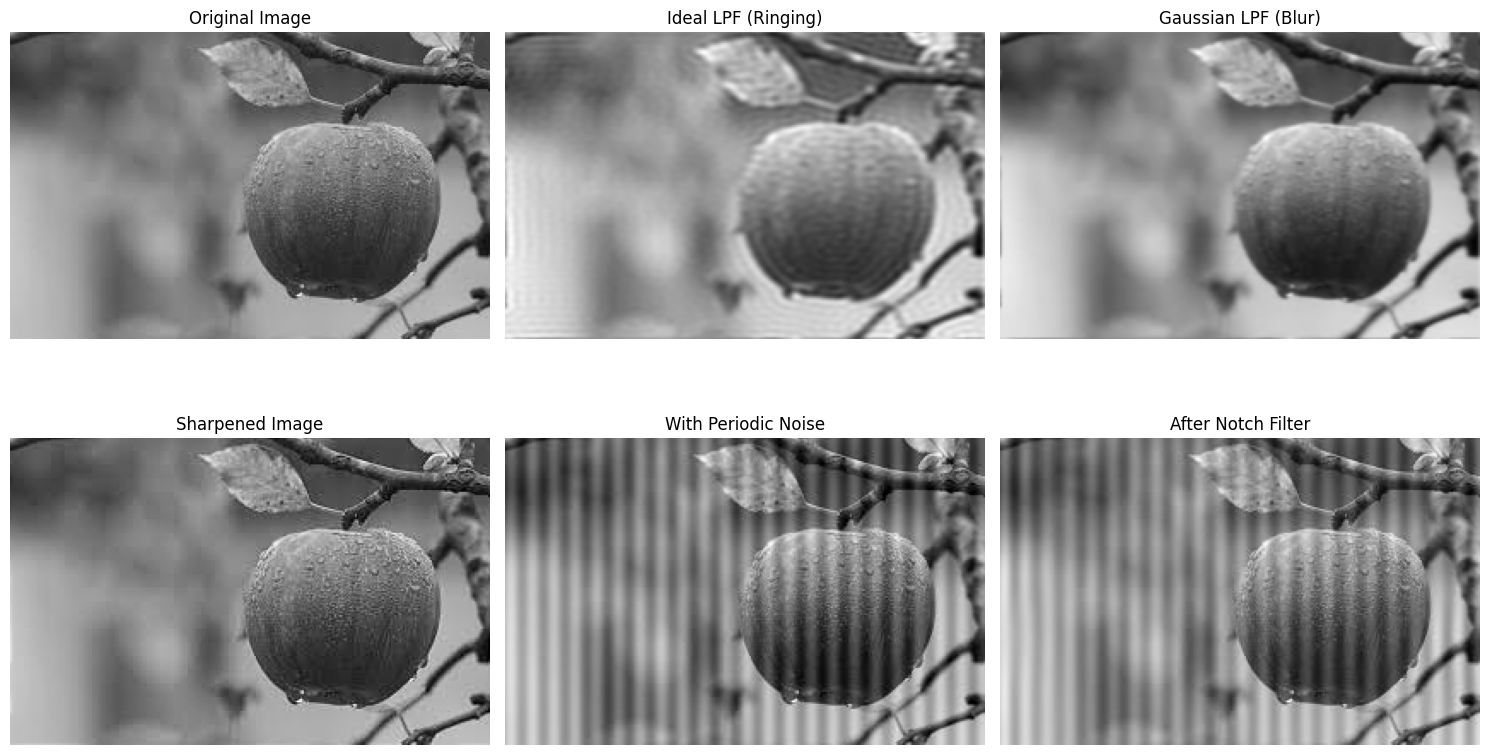

In [13]:
# --- 6. Final Visualization ---
plt.figure(figsize=(15, 9))

plt.subplot(2, 3, 1); plt.imshow(img, cmap='gray'); plt.title("Original Image"); plt.axis('off')
plt.subplot(2, 3, 2); plt.imshow(out_ideal, cmap='gray'); plt.title("Ideal LPF (Ringing)"); plt.axis('off')
plt.subplot(2, 3, 3); plt.imshow(out_gauss, cmap='gray'); plt.title("Gaussian LPF (Blur)"); plt.axis('off')
plt.subplot(2, 3, 4); plt.imshow(sharp_img, cmap='gray'); plt.title("Sharpened Image"); plt.axis('off')
plt.subplot(2, 3, 5); plt.imshow(img_noisy, cmap='gray'); plt.title("With Periodic Noise"); plt.axis('off')
plt.subplot(2, 3, 6); plt.imshow(out_notch, cmap='gray'); plt.title("After Notch Filter"); plt.axis('off')

plt.tight_layout()
plt.show()

# Comparison & Reflection
**Frequency Interpretation:** Low frequencies represent the general shape (the apple body), while high frequencies represent details (water drops and edges).

**Ringing vs Blur:** The Ideal Filter causes "Ringing" because of its sharp cutoff in the spectrum. The Gaussian Filter is much better for smooth blurring without artifacts.

**Periodic Noise:** It is much easier to remove in the frequency domain because we can see the noise as specific "spikes" and remove them using a Notch Filter without losing the image details.

# reflection questions

. **Why is frequency domain filtering often more intuitive for periodic noise?**

 Answer: Periodic noise appears as distinct, bright spikes or dots in the frequency spectrum. This makes it very easy to identify the exact location of the noise and remove it using a Notch filter without affecting the rest of the image details. In the spatial domain, this noise is mixed with all pixels, making it harder to isolate.

 **Why does a sharp cutoff in the spectrum lead to spatial ringing?**

  Answer: A sharp cutoff (like in the Ideal Low Pass Filter)  corresponds to a Sinc function in the spatial domain. The Sinc function has "ripples" or oscillations that extend outward. When we convolve the image with this sharp filter, these oscillations appear as "ringing" artifacts (ghost-like shadows) around the edges.